In [1]:
import torch
import torch.nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

#1. Data Loading and Exploration

In [2]:
BATCH_SIZE = 32
SEED = 42
device = "cpu"

In [3]:
train_data = datasets.MNIST(root="data",
                            train=True,
                            download=True,
                            transform=ToTensor())
test_data = datasets.MNIST(root="data",
                           train=False,
                           download=True,
                           transform=ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.13MB/s]


In [4]:
print(len(train_data),len(test_data))

60000 10000


In [5]:
class_names = train_data.classes
class_names_to_idx = train_data.class_to_idx
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [6]:
train_dataloader = DataLoader(dataset=train_data,
                               batch_size = BATCH_SIZE,
                               shuffle = True)
test_dataloader = DataLoader(dataset = test_data,
                             batch_size= BATCH_SIZE,
                             shuffle = False)

torch.Size([1, 28, 28])


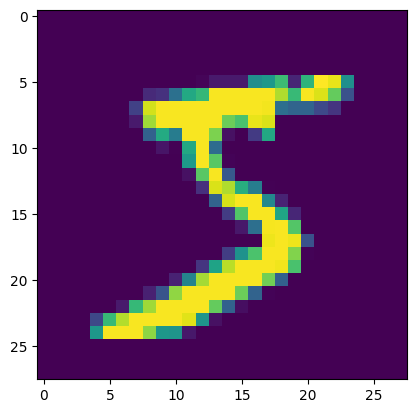

In [7]:
img,label = train_data[0]
plt.imshow(img.squeeze())
print(img.shape)

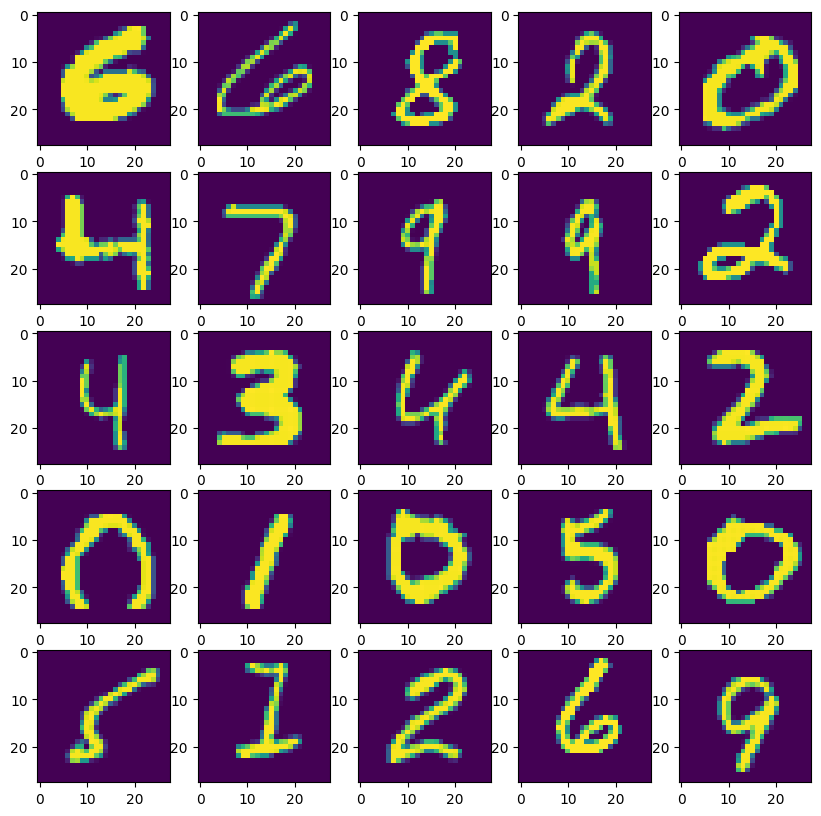

In [8]:
torch.manual_seed(SEED)
fig = plt.figure(figsize=(10,10))
rows,cols = 5,5
for i in range(1,rows*cols+1):
  img,label = train_data[torch.randint(0,len(train_data),(1,)).item()]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze())

# 2. Building the Model Training and Evaluation Functions

In [9]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device = device):
  train_loss,train_acc = 0,0
  model.train()
  for batch,(x,y)in enumerate(data_loader):
    x,y = x.to(device),y.to(device)
    y_pred = model(x)
    loss = loss_fn(y_pred,y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y,
                             y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


In [10]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              optimizer:torch.optim.Optimizer,
              accuracy_fn,
              device:torch.device = device):
  test_loss , test_acc = 0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x,y = x.to(device),y.to(device)
      test_pred = model(x)
      test_loss += loss_fn(test_pred,y)
      test_acc += accuracy_fn(y_true = y ,
                              y_pred = test_pred.argmax(dim=1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [11]:
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               accuracy_fn):
  loss,acc = 0,0
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x,y = x.to(device),y.to(device)
      y_pred = model(x)
      loss += loss_fn(y_pred,y)
      acc += accuracy_
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name":model.__class__.__name__,
          "model_loss":loss.item(),
          "model_accuracy":acc}

In [12]:
def print_train_time(start:float,end:float,device:torch.device = device):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")

In [13]:
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

# 3. Model

In [14]:
class MNISTModelV0(torch.nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack = torch.nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape,out_features = hidden_units),
        nn.Linear(in_features = hidden_units,out_features = output_shape))
  def forward(self,x):
    return self.layer_stack(x)

In [15]:
from torch import nn
model_0 = MNISTModelV0(input_shape=1*28*28,
                       hidden_units=10,
                       output_shape=len(class_names))

### 3.1 Optimizer & Loss FN

In [16]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

# 4. Train & Test Model0

In [17]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

In [18]:
torch.manual_seed(SEED)
train_time_start_for_model0 = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")
  train_step(model=model_0,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)
  test_step(model=model_0,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn)
train_time_end_for_model0 = timer()
model_0_time = print_train_time(start=train_time_start_for_model0,end=train_time_end_for_model0)
print(model_0_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Train loss: 0.40973 | Train accuracy: 88.29%
Test loss: 0.29423 | Test accuracy: 91.63%

Epoch: 1
Train loss: 0.30798 | Train accuracy: 91.31%
Test loss: 0.28632 | Test accuracy: 91.94%

Epoch: 2
Train loss: 0.29557 | Train accuracy: 91.62%
Test loss: 0.28594 | Test accuracy: 91.96%

Train time on cpu: 28.757 seconds
None


# 5. Model 1


In [19]:
from torch.nn.modules.linear import Linear
class MNISTModelV1(torch.nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_shape))
  def forward(self,x):
    return self.layer_stack(x)

### 5.1 Optimizer & Loss FN

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
model_1 = MNISTModelV1(input_shape=1*28*28,
                       hidden_units=10,
                       output_shape=len(class_names)).to(device)

In [37]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.1)

#6. Train & Test Model1

In [38]:
torch.manual_seed(SEED)
train_time_start_for_model1 = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device = device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device = device)
train_time_end_for_model1 = timer()
model_1_time = print_train_time(start=train_time_start_for_model1,end=train_time_end_for_model1,device=device)
print(model_1_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Train loss: 0.41596 | Train accuracy: 87.94%
Test loss: 0.27789 | Test accuracy: 91.70%

Epoch: 1
Train loss: 0.27683 | Train accuracy: 92.10%
Test loss: 0.24663 | Test accuracy: 93.03%

Epoch: 2
Train loss: 0.25712 | Train accuracy: 92.67%
Test loss: 0.23936 | Test accuracy: 93.29%

Train time on cuda: 31.202 seconds
None


# 7. Model 2

In [41]:
from torch.nn.modules.pooling import MaxPool2d
class MNISTModelV2(torch.nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels = hidden_units,
                  kernel_size=3,
                  stride = 1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride = 1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2))
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride = 2 ))
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape))

  def forward(self,x):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x


#8. Train & Test Model2

In [42]:
torch.manual_seed(SEED)
model_2 = MNISTModelV2(input_shape=1,
                       hidden_units=10,
                       output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

In [43]:
train_time_start_on_model2 = timer()
epoch = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device = device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Train loss: 0.26800 | Train accuracy: 91.24%
Test loss: 0.07459 | Test accuracy: 97.43%

Epoch: 1
Train loss: 0.06927 | Train accuracy: 97.83%
Test loss: 0.04383 | Test accuracy: 98.57%

Epoch: 2
Train loss: 0.05524 | Train accuracy: 98.28%
Test loss: 0.04635 | Test accuracy: 98.51%



In [45]:
import os
os.makedirs("models", exist_ok=True)

torch.save(model_2.state_dict(), "models/model_2.pth")